# E6 — Quantization You Can Feel

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Write **symmetric integer quantization** yourself, in four lines of NumPy, with no framework hiding the arithmetic
- Quantize a trained classifier to 8, 6, 5, 4, 3 and 2 bits and read the accuracy **cliff** off your own measurements
- Change one thing — **per-tensor** scales to **per-channel** scales — and measure how much of the loss comes back
- Locate where the damage is: how many weights a shared scale rounds to **zero**, and which layer loses the most signal
- Reproduce, at toy scale, the finding that protecting **1 %** of the weights recovers most of what low-bit quantization destroyed
- Report a compression result honestly: bytes, accuracy, **and** agreement with the model you actually validated

## 🔗 Where this fits

**Builds on:** Unit 5, lesson 07 `examples/07_model_optimization_quantization.ipynb` — that lesson applied PyTorch's `quantize_dynamic` to a small model and measured stored size and accuracy. It showed you that quantization works. This one opens the function: you will write the rounding yourself, go below 8 bits where `quantize_dynamic` will not follow you, and find out *where* the error lands.

**Also builds on:** Unit 5, lesson 01 `examples/01_model_optimization.ipynb`, which introduced Deep Compression's 240 MB → 6.9 MB result and named quantization as the middle stage of that pipeline, and lesson 04 `examples/04_model_pruning.ipynb`, which measured the other size/accuracy trade in the same unit.

**Used later in:** Course 11 (AIAT 125) — Unit 2, lesson 04 (serialization formats) and lesson 06 (batch vs real-time inference), where model bytes become load time, memory footprint and the number of replicas you have to pay for.

## 🌍 Why this matters: the models you can actually run are the quantized ones

**The named case.** In October 2015 Song Han, Huizi Mao and William Dally published *Deep Compression* ([arXiv:1510.00149](https://arxiv.org/abs/1510.00149)), whose abstract reports reducing storage "by 35x to 49x without affecting their accuracy" — **AlexNet from 240 MB to 6.9 MB** and **VGG-16 from 552 MB to 11.3 MB** — using pruning, trained quantization and Huffman coding together. Unit 5 lesson 01 already told you that story. What it did not tell you is that quantization is the stage of that pipeline that survived unchanged into 2026, because it is the one that costs nothing to apply.

**And the case you can check yourself, today.** Open the `config.json` of OpenAI's open-weight `gpt-oss-20b` or `gpt-oss-120b` on the Hugging Face Hub and you will find a `quantization_config` block declaring `"quant_method": "mxfp4"`. A frontier-class open model does not ship in float32, or in float16. It ships in **4 bits**, because that is the difference between a model that fits on the hardware people own and one that does not.

**Why the arithmetic below is worth doing by hand.** In 2023 Lin, Tang, Tang, Yang, Chen, Wang, Xiao, Dang, Gan and Han published *AWQ: Activation-aware Weight Quantization* ([arXiv:2306.00978](https://arxiv.org/abs/2306.00978)) with a claim that sounds impossible until you have watched the rounding happen:

> "AWQ finds that not all weights in an LLM are equally important. Protecting only 1% salient weights can greatly reduce quantization error."

You will reproduce the shape of that result in Part 5 on your own trained model. You cannot understand why one per cent of the weights can matter that much until you have seen what a single shared scale does to the other ninety-nine.

**What goes wrong without this lesson.** Two failures, and they are symmetric. The first is treating quantization as free: 8-bit usually is, 4-bit sometimes is, and 2-bit is a way of deleting a model — you will measure exactly that. The second is treating the accuracy number as the whole answer. A quantized model can score *higher* on your test set than the model you validated, purely by luck, while disagreeing with it on one prediction in a hundred. You are shipping the disagreement, not the accuracy. That is why 2026 practice adds a recovery step rather than quantizing and shipping (Ryskulov et al., [arXiv:2608.20953](https://arxiv.org/abs/2608.20953)).

## 📥 Inputs & 📤 Outputs

**Inputs:** `sklearn.datasets.load_digits` — **1,797 real 8×8 handwritten digit images** from the UCI Optical Recognition of Handwritten Digits set, bundled with scikit-learn. No downloads, no network, no synthetic data anywhere in this notebook. The model is a small `MLPClassifier` trained here in under a second.

**Outputs:** a byte-for-byte size table at six bit-widths and two scale granularities, accuracy **and** prediction-agreement for each, the fraction of weights each setting rounds to zero, a weight histogram with the integer grid drawn over it, per-layer signal-to-quantization-noise ratios, and a 1 %-protection experiment.

**Runtime:** a few seconds on a CPU — the last cell prints the measured total.

## Part 1: A Real Model, and a Forward Pass We Control

Quantization changes weights. To see what that does, we need to run the network ourselves rather than calling `clf.predict`, because after quantization the weights no longer live inside the scikit-learn object.

So the first cell trains the classifier and then re-implements its forward pass in three lines of NumPy — `a = ReLU(a @ W + b)` per hidden layer, `argmax` at the end — and checks that the hand-written version reproduces `clf.predict` exactly. If it does not, nothing downstream means anything.

In [1]:
# WHAT: train a small MLP on the bundled handwritten-digit images, then re-implement its
#       forward pass in NumPy and verify it reproduces scikit-learn's predictions exactly.
# WHY:  quantization edits the weight arrays. We can only measure the effect if we own the
#       matrix multiply — and we can only trust our forward pass if we check it first.
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt          # the notebook kernel renders inline; no window is opened
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

NOTEBOOK_START = time.perf_counter()

digits = load_digits()
X = digits.data / 16.0                    # pixel values are 0-16; scale to 0-1
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=600, random_state=42)
clf.fit(X_train, y_train)

# The trained parameters, lifted out of the estimator so we can edit them.
WEIGHTS = [w.copy() for w in clf.coefs_]        # one matrix per layer
BIASES = [b.copy() for b in clf.intercepts_]    # biases stay in float throughout: see Part 2

def forward(weights, biases, inputs):
    """The MLP's forward pass, written out: ReLU between layers, raw logits at the end."""
    a = inputs
    for i, (w, b) in enumerate(zip(weights, biases)):
        a = a @ w + b
        if i < len(weights) - 1:
            a = np.maximum(a, 0.0)               # ReLU
    return a

BASE_LOGITS = forward(WEIGHTS, BIASES, X_test)
BASE_PRED = BASE_LOGITS.argmax(axis=1)
BASE_ACC = accuracy_score(y_test, BASE_PRED)

print(f"Dataset : {digits.data.shape[0]:,} images of {digits.images.shape[1]}x"
      f"{digits.images.shape[2]} pixels, {len(np.unique(y))} classes")
print(f"Split   : {len(X_train):,} train / {len(X_test):,} test")
print(f"Network : {X.shape[1]} -> " + " -> ".join(str(w.shape[1]) for w in WEIGHTS)
      + f"   (converged in {clf.n_iter_} iterations)\n")
for i, (w, b) in enumerate(zip(WEIGHTS, BIASES)):
    print(f"  layer {i}: weights {str(w.shape):>10}  = {w.size:6,} numbers   biases {b.size:>4}")
n_weights = sum(w.size for w in WEIGHTS)
n_biases = sum(b.size for b in BIASES)
print(f"  total  : {n_weights:,} weights + {n_biases} biases, stored by scikit-learn as "
      f"{WEIGHTS[0].dtype}\n")

print(f"scikit-learn accuracy : {accuracy_score(y_test, clf.predict(X_test)):.4f}")
print(f"our forward pass      : {BASE_ACC:.4f}")
print(f"identical predictions : {np.array_equal(clf.predict(X_test), BASE_PRED)}")

Dataset : 1,797 images of 8x8 pixels, 10 classes
Split   : 1,257 train / 540 test
Network : 64 -> 128 -> 64 -> 10   (converged in 148 iterations)

  layer 0: weights  (64, 128)  =  8,192 numbers   biases  128
  layer 1: weights  (128, 64)  =  8,192 numbers   biases   64
  layer 2: weights   (64, 10)  =    640 numbers   biases   10
  total  : 17,024 weights + 202 biases, stored by scikit-learn as float64

scikit-learn accuracy : 0.9796
our forward pass      : 0.9796
identical predictions : True


## Part 2: The Arithmetic, In Full

**Symmetric integer quantization** is one idea. A weight matrix spans some range; an integer of *b* bits can hold `2^(b-1) − 1` positive levels. So pick a step size that maps the largest weight onto the largest integer, and round everything onto that grid:

```
q_max = 2^(b-1) − 1
scale = max(|W|) / q_max          # one real number per tensor
codes = clip(round(W / scale), −q_max, +q_max)     # integers — this is what you store
W'    = codes × scale             # what the model computes with
```

Three things are worth staring at before you run it:

- **The scale is set by the single largest weight.** Every other weight in the tensor is rounded onto a grid whose spacing that one outlier chose. This is the whole story of Part 4.
- **Biases stay in float.** There are 202 of them against 17,024 weights; quantizing them saves nothing and costs accuracy. Real toolchains make the same choice.
- **`codes` is the artifact.** You ship the integers plus the scale. `W'` never exists on disk — it is reconstructed, or better, the integer is used directly by an integer kernel.

We start where nobody argues: **8 bits.**

In [2]:
# WHAT: implement symmetric quantization, apply it at 8 bits, and account for the bytes.
# WHY:  8-bit is the setting everyone calls "free". This cell checks that claim on our model
#       and sets up the two numbers every later experiment reports: size and behaviour.
def quantize(w, bits, per_channel=False):
    """Symmetric integer quantization. Returns (dequantized weights, integer codes, scales)."""
    q_max = 2 ** (bits - 1) - 1
    if per_channel:
        # one scale per OUTPUT neuron, i.e. per column of the weight matrix
        scale = np.abs(w).max(axis=0, keepdims=True) / q_max
    else:
        scale = np.full((1, 1), np.abs(w).max() / q_max)     # one scale for the whole tensor
    scale = np.where(scale == 0, 1e-12, scale)               # a dead neuron would divide by zero
    codes = np.clip(np.rint(w / scale), -q_max, q_max)       # <- the integers you would ship
    return codes * scale, codes, scale

def stored_bytes(bits, per_channel):
    """Bytes on disk: packed integer weights + float32 scales + float32 biases."""
    weight_bits = n_weights * bits
    n_scales = sum(w.shape[1] for w in WEIGHTS) if per_channel else len(WEIGHTS)
    return weight_bits / 8 + n_scales * 4 + n_biases * 4

def evaluate(weights):
    """Accuracy, agreement with the validated model, and the largest logit disturbance."""
    logits = forward(weights, BIASES, X_test)
    pred = logits.argmax(axis=1)
    return (accuracy_score(y_test, pred),
            float((pred == BASE_PRED).mean()),
            float(np.abs(logits - BASE_LOGITS).max()))

fp32_bytes = n_weights * 4 + n_biases * 4
fp64_bytes = (n_weights + n_biases) * 8
int8 = [quantize(w, 8)[0] for w in WEIGHTS]
acc8, agree8, dlogit8 = evaluate(int8)

print("WHAT THE MODEL COSTS")
print(f"  as scikit-learn stores it (float64) : {fp64_bytes / 1024:8.1f} KiB")
print(f"  as you would ship it     (float32)  : {fp32_bytes / 1024:8.1f} KiB   <- the honest baseline")
print(f"  8-bit weights + float scales/biases : {stored_bytes(8, False) / 1024:8.1f} KiB   "
      f"({fp32_bytes / stored_bytes(8, False):.2f}x smaller)\n")

print("WHAT IT COSTS YOU")
print(f"  float32 accuracy      : {BASE_ACC:.4f}")
print(f"  8-bit accuracy        : {acc8:.4f}   ({(acc8 - BASE_ACC) * 100:+.2f} pp)")
print(f"  predictions unchanged : {agree8:.4f} of the {len(y_test)} test images")
print(f"  largest logit shift   : {dlogit8:.4f}\n")

layer0 = WEIGHTS[0]
_, codes0, scale0 = quantize(layer0, 8)
print(f"Layer 0, concretely: weights run from {layer0.min():+.4f} to {layer0.max():+.4f};")
print(f"the 8-bit step is {scale0.item():.6f}, so the rounded integers span "
      f"{int(codes0.max() - codes0.min()) + 1} of the 255 levels an 8-bit code can hold.")

WHAT THE MODEL COSTS
  as scikit-learn stores it (float64) :    134.6 KiB
  as you would ship it     (float32)  :     67.3 KiB   <- the honest baseline
  8-bit weights + float scales/biases :     17.4 KiB   (3.86x smaller)

WHAT IT COSTS YOU
  float32 accuracy      : 0.9796
  8-bit accuracy        : 0.9796   (+0.00 pp)
  predictions unchanged : 1.0000 of the 540 test images
  largest logit shift   : 0.1339

Layer 0, concretely: weights run from -0.6573 to +0.6189;
the 8-bit step is 0.005176, so the rounded integers span 248 of the 255 levels an 8-bit code can hold.


## Part 3: The Comparative Experiment — How Low Can You Go, and Does the Scale Help?

**Baseline:** 8-bit, one scale for the whole tensor.

**Change one thing at a time:**
1. the **bit width** — 8, 6, 5, 4, 3, 2 — keeping one scale per tensor;
2. the **scale granularity** — one scale per *output neuron* instead of one per tensor — keeping everything else identical. Per-channel scaling costs a handful of extra floats and lets a layer with one loud neuron stop punishing all the others.

Two quality numbers are reported for every setting, and the difference between them is the point:

- **accuracy** — how often it is right. This is what a report will quote.
- **agreement** — how often it makes the *same prediction as the float32 model you validated*. This is what you are actually shipping. Accuracy can rise while agreement falls; that is noise being mistaken for improvement.

In [3]:
# WHAT: sweep six bit widths at both scale granularities, recording bytes, accuracy,
#       agreement with the float32 model, and how many weights were rounded to zero.
# WHY:  one variable at a time, one table. The shape of the accuracy column is the lesson,
#       and the gap between the accuracy and agreement columns is the warning.
rows = []
for bits in (8, 6, 5, 4, 3, 2):
    for per_channel in (False, True):
        triples = [quantize(w, bits, per_channel) for w in WEIGHTS]
        acc, agree, dlogit = evaluate([t[0] for t in triples])
        zeroed = sum(int((t[1] == 0).sum()) for t in triples) / n_weights
        size = stored_bytes(bits, per_channel)
        rows.append({"bits": bits,
                     "scales": "per-channel" if per_channel else "per-tensor",
                     "KiB": size / 1024,
                     "vs fp32": f"{fp32_bytes / size:.1f}x",
                     "accuracy": acc,
                     "acc delta pp": (acc - BASE_ACC) * 100,
                     "agreement": agree,
                     "max logit shift": dlogit,
                     "weights zeroed": zeroed})
sweep = pd.DataFrame(rows)

print(f"float32 reference: {fp32_bytes / 1024:.1f} KiB, accuracy {BASE_ACC:.4f}, "
      f"agreement 1.0000 by definition\n")
print(sweep.to_string(index=False, formatters={
    "KiB": "{:.1f}".format, "accuracy": "{:.4f}".format, "acc delta pp": "{:+.2f}".format,
    "agreement": "{:.4f}".format, "max logit shift": "{:.3f}".format,
    "weights zeroed": "{:.1%}".format}))

per_tensor = sweep[sweep["scales"] == "per-tensor"].set_index("bits")
per_channel = sweep[sweep["scales"] == "per-channel"].set_index("bits")
print(f"\nAt 4 bits the tensor-wide scale costs {(BASE_ACC - per_tensor.loc[4, 'accuracy']) * 100:.2f} "
      f"pp of accuracy; switching to per-neuron scales recovers "
      f"{(per_channel.loc[4, 'accuracy'] - per_tensor.loc[4, 'accuracy']) * 100:.2f} pp of it "
      f"for {int(stored_bytes(4, True) - stored_bytes(4, False))} extra bytes.")
print(f"At 2 bits the same change moves accuracy from {per_tensor.loc[2, 'accuracy']:.4f} to "
      f"{per_channel.loc[2, 'accuracy']:.4f} — and neither is a model you could ship.")

float32 reference: 67.3 KiB, accuracy 0.9796, agreement 1.0000 by definition

 bits      scales  KiB vs fp32 accuracy acc delta pp agreement max logit shift weights zeroed
    8  per-tensor 17.4    3.9x   0.9796        +0.00    1.0000           0.134          14.3%
    8 per-channel 18.2    3.7x   0.9796        +0.00    1.0000           0.104          12.2%
    6  per-tensor 13.3    5.1x   0.9796        +0.00    0.9963           0.530          17.8%
    6 per-channel 14.0    4.8x   0.9833        +0.37    0.9926           0.512          14.6%
    5  per-tensor 11.2    6.0x   0.9796        +0.00    0.9963           1.604          22.8%
    5 per-channel 12.0    5.6x   0.9815        +0.19    0.9907           0.981          17.5%
    4  per-tensor  9.1    7.4x   0.9722        -0.74    0.9870           3.364          33.2%
    4 per-channel  9.9    6.8x   0.9778        -0.19    0.9981           2.064          24.1%
    3  per-tensor  7.0    9.6x   0.9593        -2.04    0.9648           7.9

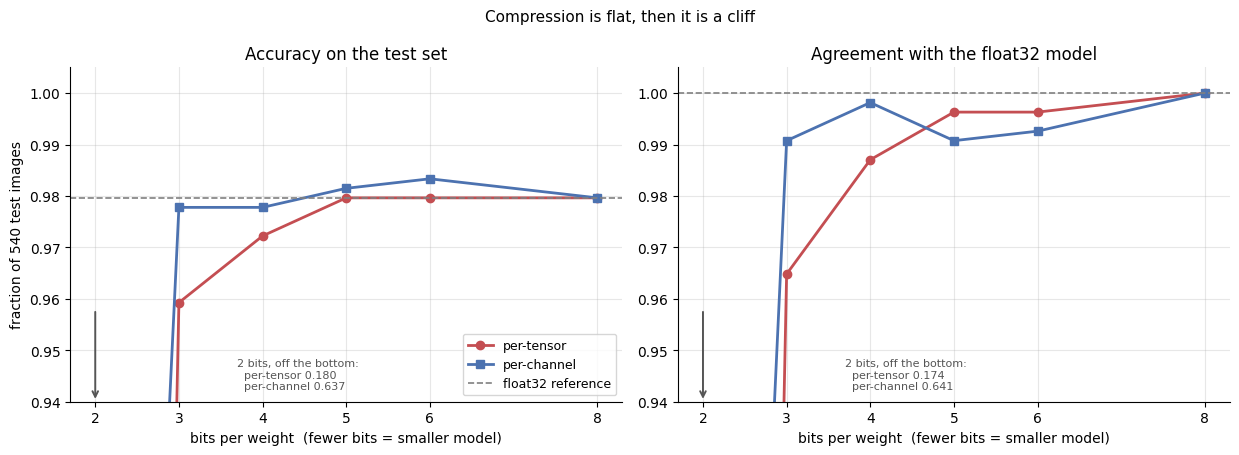

In [4]:
# WHAT: plot accuracy and agreement against bit width for both scale granularities.
# WHY:  the table has the numbers; the chart has the shape. Compression is not a dial you turn
#       down smoothly — it is flat, then it is a cliff, and you need to know where the edge is.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
styles = {"per-tensor": ("#C44E52", "o-"), "per-channel": ("#4C72B0", "s-")}
Y_FLOOR = 0.94          # the 2-bit points fall far below this; they are labelled instead

for metric, ax, title in (("accuracy", axes[0], "Accuracy on the test set"),
                          ("agreement", axes[1], "Agreement with the float32 model")):
    off_scale = []
    for mode, (color, style) in styles.items():
        sub = sweep[sweep["scales"] == mode].sort_values("bits")
        ax.plot(sub["bits"], sub[metric], style, color=color, lw=2, label=mode)
        off_scale.append(f"{mode} {sub[sub['bits'] == 2][metric].item():.3f}")
    ax.axhline(BASE_ACC if metric == "accuracy" else 1.0, ls="--", color="gray", lw=1.2,
               label="float32 reference")
    ax.annotate("", xy=(2, Y_FLOOR), xytext=(2, Y_FLOOR + 0.018),
                arrowprops=dict(arrowstyle="->", color="#555555", lw=1.4))
    label = "2 bits, off the bottom:" + "".join("\n  " + t for t in off_scale)
    ax.text(3.7, Y_FLOOR + 0.002, label, fontsize=8, color="#555555", va="bottom")
    ax.set_ylim(Y_FLOOR, 1.005)
    ax.set_xlabel("bits per weight  (fewer bits = smaller model)")
    ax.set_title(title)
    ax.set_xticks([2, 3, 4, 5, 6, 8])
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("fraction of 540 test images")
axes[0].legend(loc="lower right", fontsize=9)
fig.suptitle("Compression is flat, then it is a cliff", fontsize=11)
plt.tight_layout()
plt.show()

### Conclusion the printed numbers support

**8 bits is free, and that is a measurement rather than a slogan.** 67.3 KiB → 17.4 KiB, a **3.9×** reduction, at identical accuracy (0.9796) and an agreement of **1.0000**: not one of the 540 test predictions changed. This is why 8-bit quantization is applied by default and argued about by nobody.

**The cliff sits between 3 and 2 bits, and it really is a cliff.** With one scale per tensor, accuracy runs 0.9796, 0.9796, 0.9796, 0.9722, 0.9593 as you go from 8 bits down to 3 — and then falls to **0.1796** at 2 bits, barely above the 10 % you would get by guessing. There is no smooth trade-off curve to negotiate along: there is a usable region and an edge, and the only way to know where the edge is for *your* model is to measure it.

**Per-channel scales are the cheapest line on the table.** At 4 bits, one scale per tensor costs 0.74 pp of accuracy; one scale per output neuron costs **0.19 pp**, and its agreement of **0.9981** is the highest of any setting below 8 bits. The price is **796 bytes** — 199 extra float32 scales on a 9.1 KiB artifact. At 3 bits the same change is worth 1.85 pp. If your quantizer offers per-channel scales, there is no argument for declining them.

**And the accuracy column will mislead you if you let it.** 6-bit per-channel scores **0.9833**, which is **0.37 pp above the float32 model it is compressing**. It did not get better. Its agreement is 0.9926, so it changed **four** of the 540 predictions and happened to net two of them in its favour, on a test set where a single image is worth 0.19 pp. Accuracy is what your report will quote; agreement is what your users will experience.

## Part 4: Where the Error Concentrates

The sweep says the model breaks somewhere below 4 bits. It does not say *what* breaks. Two measurements answer that.

**How many weights get rounded to zero.** With one scale per tensor, the step is `max(|W|) / q_max`. Any weight smaller than half a step becomes the integer `0` — deleted. At 8 bits that catches only the genuinely negligible weights. At 3 bits, `q_max = 3`, so the step is a third of the largest weight and everything below one sixth of the maximum disappears. Quantization has quietly become pruning, and nobody chose the pruning threshold.

**Signal-to-quantization-noise ratio, per layer.** `SQNR = 10·log10(‖W‖² / ‖W − W'‖²)`, in decibels: how much of each layer survived. Layers differ, because the ratio between a layer's largest weight and its typical weight differs.

 bits                layer 0               layer 1               layer 2
           zeroed    SQNR dB     zeroed    SQNR dB     zeroed    SQNR dB
    8      13.8%       39.7      15.4%       40.6       7.5%       44.2 
    5      22.8%       21.1      23.6%       22.1      13.8%       25.6 
    4      33.4%       14.5      33.9%       15.4      20.2%       18.9 
    3      59.2%        7.2      57.5%        8.0      35.0%       11.4 
    2      98.7%        0.2      96.9%        0.6      81.2%        1.6 

Layer 0: largest |weight| = 0.6573, median |weight| = 0.0852 — a ratio of 7.7.
That ratio is the problem. One weight chooses the grid; the median weight lives on it.


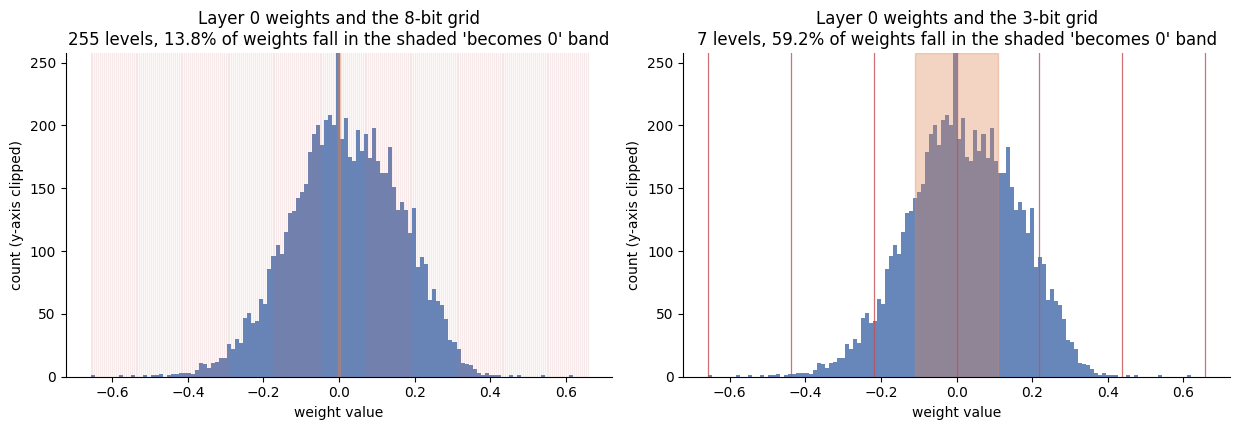

Left: at 8 bits the 255 grid lines are finer than the histogram's own bins — drawn faint so you can still
see the weights underneath. Right: at 3 bits there are 7 lines, and the shaded band is the
set of weights the model is about to lose entirely.

About the spike at zero (clipped by the y-axis): 887 of layer 0's 8,192 weights were
already below 1e-6 in float32. 512 of those belong to the 4 input pixels that are blank
in every training image; the rest were shrunk to nothing by the L2 penalty because their
input carried almost no signal. So part of the 'weights zeroed' column is quantization
deleting weights that were already dead — know that before you quote it as a pruning result.


In [5]:
# WHAT: measure, per layer and per bit width, the fraction of weights rounded to zero and the
#       signal-to-quantization-noise ratio; then draw the 4-bit grid over the real histogram.
# WHY:  "accuracy dropped" is a symptom. This cell shows the mechanism: one outlier sets the
#       step, and everything small is rounded into nothing.
print(f"{'bits':>5} " + "".join(f"{'layer ' + str(i):>22}" for i in range(len(WEIGHTS))))
print(f"{'':>5} " + "".join(f"{'zeroed':>11}{'SQNR dB':>11}" for _ in WEIGHTS))
for bits in (8, 5, 4, 3, 2):
    line = f"{bits:>5} "
    for w in WEIGHTS:
        wq, codes, _ = quantize(w, bits)
        sqnr = 10 * np.log10((w ** 2).sum() / max(((w - wq) ** 2).sum(), 1e-30))
        line += f"{(codes == 0).mean():>10.1%} {sqnr:>10.1f} "
    print(line)

layer = WEIGHTS[0]
outlier_ratio = np.abs(layer).max() / np.median(np.abs(layer))
print(f"\nLayer 0: largest |weight| = {np.abs(layer).max():.4f}, median |weight| = "
      f"{np.median(np.abs(layer)):.4f} — a ratio of {outlier_ratio:.1f}.")
print("That ratio is the problem. One weight chooses the grid; the median weight lives on it.")

# The tall spike at zero in the charts below is real, and worth explaining before we blame
# quantization for it: some weights were already ~0 in float32 because their input pixel carries
# no signal and the L2 penalty (MLPClassifier's default alpha) shrank them to nothing.
dead_pixels = int((X_train.max(axis=0) == 0).sum())
already_zero = int((np.abs(layer) < 1e-6).sum())
counts, _ = np.histogram(layer.ravel(), bins=120)
y_cap = np.sort(counts)[-3] * 1.25          # clip the always-zero spike so the bulk is readable

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for ax, bits in zip(axes, (8, 3)):
    _, _, scale = quantize(layer, bits)
    step = scale.item()
    q_max = 2 ** (bits - 1) - 1
    ax.hist(layer.ravel(), bins=120, color="#4C72B0", alpha=0.85)
    grid_alpha = max(0.12, min(0.8, 10 / (2 * q_max + 1)))   # dense grids drawn faint on purpose
    for level in range(-q_max, q_max + 1):
        ax.axvline(level * step, color="#C44E52", lw=0.9, alpha=grid_alpha)
    zeroed = (np.abs(layer) < step / 2).mean()
    ax.axvspan(-step / 2, step / 2, color="#DD8452", alpha=0.35)
    ax.set_ylim(0, y_cap)
    ax.set_title(f"Layer 0 weights and the {bits}-bit grid\n"
                 f"{2 * q_max + 1} levels, {zeroed:.1%} of weights fall in the shaded 'becomes 0' band")
    ax.set_xlabel("weight value")
    ax.set_ylabel("count (y-axis clipped)")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Left: at 8 bits the {2 * 127 + 1} grid lines are finer than the histogram's own bins — "
      f"drawn faint so you can still")
print("see the weights underneath. Right: at 3 bits there are 7 lines, and the shaded band is the")
print("set of weights the model is about to lose entirely.\n")
print(f"About the spike at zero (clipped by the y-axis): {already_zero:,} of layer 0's "
      f"{layer.size:,} weights were")
print(f"already below 1e-6 in float32. {dead_pixels * layer.shape[1]:,} of those belong to the "
      f"{dead_pixels} input pixels that are blank")
print("in every training image; the rest were shrunk to nothing by the L2 penalty because their")
print("input carried almost no signal. So part of the 'weights zeroed' column is quantization")
print("deleting weights that were already dead — know that before you quote it as a pruning result.")

## 💬 Discuss

1. The sweep reports settings where accuracy went **up** relative to float32 while agreement went **down** — 6-bit per-channel is the clearest. A colleague writes in the release notes: "6-bit quantization improved test accuracy by 0.37 points." Say precisely what is wrong with that sentence, and propose the sentence you would put in the release notes instead.
2. Per-channel scales cost a few hundred extra bytes and recovered most of the 4-bit loss. Extrapolate the idea: what would per-**row** scales cost and buy, and at what granularity does the overhead stop being worth it? Do the arithmetic for layer 0 before you answer.
3. Part 4 shows quantization silently zeroing a large fraction of the weights. Unit 5 lesson 04 taught pruning, where you choose that threshold deliberately and can retrain afterwards. Which of the two would you rather apply first to a model you have to ship next week, and what would you measure to defend the order you chose?

## Part 5: The One Per Cent That Matters

Return to AWQ's claim: *"Protecting only 1% salient weights can greatly reduce quantization error."* On our model at 3 bits, the accuracy has already fallen and 57 % of the weights have been rounded away. Suppose we are allowed to keep a tiny handful of weights in full precision and quantize the rest. Which ones?

Two candidate rules for "salient", both cheap:
- **largest |w|** — the weights carrying the most magnitude;
- **largest |w| · E|x|** — magnitude weighted by how strongly the corresponding *input channel* actually activates, measured on data.

The second is the shape of AWQ's own answer: its abstract says "To identify salient weight channels, we should refer to the activation distribution, not weights." Whether that holds on a 64-pixel digit classifier is an empirical question, and we are going to answer it rather than assume it.

In [6]:
# WHAT: quantize to 3 and 4 bits while keeping 1% of the weights in float, choosing that 1%
#       two different ways, and measure what each choice recovers.
# WHY:  this is the smallest honest test of AWQ's headline claim. It also shows what a toy
#       model can and cannot tell you about a result that was established on LLMs.
def mean_abs_activations(inputs):
    """Mean |activation| entering each layer, measured on real data — the 'E|x|' in AWQ's rule."""
    stats, a = [], inputs
    for i, (w, b) in enumerate(zip(WEIGHTS, BIASES)):
        stats.append(np.abs(a).mean(axis=0))       # one number per input channel of this layer
        a = a @ w + b
        if i < len(WEIGHTS) - 1:
            a = np.maximum(a, 0.0)
    return stats

ACT = mean_abs_activations(X_test)

def quantize_protecting(w, bits, salience, keep_fraction=0.01):
    """Quantize per-tensor, but leave the top `keep_fraction` of weights by salience untouched."""
    k = max(1, int(round(keep_fraction * w.size)))
    keep = np.zeros(w.size, dtype=bool)
    keep[np.argsort(salience.ravel())[-k:]] = True
    keep = keep.reshape(w.shape)
    # Excluding the protected weights also removes them from the max() that sets the scale —
    # which is half of why protection helps.
    rest = np.where(keep, 0.0, w)
    dequantized, _, _ = quantize(rest, bits)
    return np.where(keep, w, dequantized)

rules = {
    "no protection": None,
    "protect 1% by |w|": lambda i: np.abs(WEIGHTS[i]),
    "protect 1% by |w| x E|x|": lambda i: np.abs(WEIGHTS[i]) * ACT[i][:, None],
}

print(f"{'bits':>5} {'rule':>26} {'accuracy':>10} {'agreement':>11} {'max logit shift':>17}")
protection = []
for bits in (4, 3):
    for name, salience in rules.items():
        if salience is None:
            weights = [quantize(w, bits)[0] for w in WEIGHTS]
        else:
            weights = [quantize_protecting(WEIGHTS[i], bits, salience(i)) for i in range(len(WEIGHTS))]
        acc, agree, dlogit = evaluate(weights)
        protection.append({"bits": bits, "rule": name, "accuracy": acc, "agreement": agree})
        print(f"{bits:>5} {name:>26} {acc:>10.4f} {agree:>11.4f} {dlogit:>17.4f}")

prot = pd.DataFrame(protection).set_index(["bits", "rule"])
gain3 = prot.loc[(3, "protect 1% by |w|"), "accuracy"] - prot.loc[(3, "no protection"), "accuracy"]
extra_bytes = int(0.01 * n_weights * 4)     # the protected weights, stored as float32
print(f"\nAt 3 bits, protecting 1% of the weights by magnitude recovers "
      f"{gain3 * 100:+.2f} pp of accuracy")
print(f"for about {extra_bytes:,} extra bytes — {100 * extra_bytes / stored_bytes(3, False):.0f}% "
      f"on top of the 3-bit artifact.")
print(f"\nThe activation-weighted rule did NOT beat plain magnitude on this model. Read that as")
print(f"information about the model, not about AWQ — see 'Where this breaks' below.")
print(f"\nTotal notebook runtime: {time.perf_counter() - NOTEBOOK_START:.1f} s")

 bits                       rule   accuracy   agreement   max logit shift
    4              no protection     0.9722      0.9870            3.3643
    4          protect 1% by |w|     0.9796      0.9852            1.8105
    4   protect 1% by |w| x E|x|     0.9741      0.9815            3.0933
    3              no protection     0.9593      0.9648            7.9798
    3          protect 1% by |w|     0.9685      0.9778            3.9792
    3   protect 1% by |w| x E|x|     0.9537      0.9556            8.9455

At 3 bits, protecting 1% of the weights by magnitude recovers +0.93 pp of accuracy
for about 680 extra bytes — 9% on top of the 3-bit artifact.

The activation-weighted rule did NOT beat plain magnitude on this model. Read that as
information about the model, not about AWQ — see 'Where this breaks' below.

Total notebook runtime: 0.6 s


## ⚠️ Where this breaks

**A 17,000-weight MLP is not a language model, and the differences are exactly the ones that matter here.** The reason AWQ selects salient channels by *activation* is that transformer activations contain extreme outlier channels — a small number of dimensions with magnitudes far above the rest. A 64-pixel normalized image has nothing of the kind, which is why our activation-weighted rule had almost nothing to weight with and did not beat plain magnitude. Our Part 5 result reproduces the *first* half of AWQ's claim (a tiny protected set recovers a lot) and cannot test the *second* (that activations identify the right set). Do not report it as evidence either way about AWQ.

**Nor is our protection scheme what AWQ does.** We froze individual weights in float, which is mixed precision — the thing AWQ's abstract explicitly avoids as "hardware-inefficient". AWQ instead derives an equivalent per-channel *scaling* that protects salient channels while every weight stays at the same bit width. Our version is the pedagogical ancestor of the technique, not the technique.

**We measured memory, not speed, and the notebook cannot measure speed honestly.** After quantizing we multiply `codes × scale` back into float64 and hand that to NumPy. Nothing here runs faster; real gains need integer kernels (or MXFP4 hardware) that NumPy does not provide. Everything in Unit 5 lesson 07 about *latency* still needs a real runtime to demonstrate. What this notebook does show — bytes, accuracy, agreement, and where the error lands — is exactly the part that transfers.

**Weight-only quantization is the easy half.** Activations are usually quantized too, and they are harder: their range depends on the input, so the scale must either be calibrated on sample data or computed at run time. Everything above assumes float activations.

**540 test images make a coarse ruler.** One image is 0.19 percentage points. Several of the differences in the sweep are one or two images wide, and the case where 6-bit "beat" float32 is exactly that — noise, which is why the agreement column exists. Do not rank quantization settings on this test set; rank them on agreement, and confirm on something larger.

**And no recovery step was applied.** 2026 practice for aggressive compression is quantize-*then*-heal: Ryskulov and colleagues ([arXiv:2608.20953](https://arxiv.org/abs/2608.20953)) report that distilling the 4-bit student directly from the original uncompressed model reached a comparable peak "about 7 times faster" than quantization-aware training and "stays stable under continued training". The 3-bit and 2-bit rows in our sweep are what quantize-and-ship looks like with the recovery stage missing.

## ✅ Summary

**What you actually did** (every number above was computed when this notebook ran):

- Trained a real classifier on real bundled images and re-implemented its forward pass so you owned the arithmetic
- Wrote symmetric integer quantization from the formula and applied it at six bit widths
- Measured bytes, accuracy, agreement with the validated model, and the largest logit disturbance for each
- Changed one thing — per-tensor to per-channel scales — and measured how much of the low-bit loss came back for a few hundred bytes
- Located the damage: the fraction of weights rounded to zero, per-layer SQNR, and the outlier that chose the grid
- Protected 1 % of the weights, two different ways, and reported the result honestly including the part that did not work

**The one sentence to keep:** the scale is chosen by the largest weight in the tensor, so quantization error is not spread evenly — it is concentrated on everything that is *not* the outlier, which is why the cheapest fixes are all about giving fewer weights a shared scale.

**Where this goes next.** The compression frontier you plotted is the same one that decides whether a model runs on a phone, in a browser tab, or on a classroom laptop with no GPU — and the KV cache, which quantizes on exactly the same principles, is the other half of that budget (Course 11, Unit 2 enrichment). If you want the 2026 practitioner's version of this notebook, read AWQ first for the mechanism and the healing recipe second for what you do after the bits are gone.

## 📚 References

Each entry below was checked against its arXiv abstract page while this notebook was written.

1. Han, S., Mao, H., & Dally, W. J. (2015). *Deep Compression: Compressing Deep Neural Networks with Pruning, Trained Quantization and Huffman Coding*. ICLR 2016. [arXiv:1510.00149](https://arxiv.org/abs/1510.00149) — the 35×–49× result, and the source of the AlexNet and VGG-16 figures quoted above.
2. Lin, J., Tang, J., Tang, H., Yang, S., Chen, W.-M., Wang, W.-C., Xiao, G., Dang, X., Gan, C., & Han, S. (2023). *AWQ: Activation-aware Weight Quantization for LLM Compression and Acceleration*. [arXiv:2306.00978](https://arxiv.org/abs/2306.00978) — the 1 %-salient-weights finding tested in Part 5, and the reason production quantizers scale channels rather than freeze weights.
3. Ryskulov, B., García-Ferrero, I., Montero, D., Jansen, D., Hashemi, A., Garcia, J. R., Tiene, A., & Orús, R. (2026). *Quantization-Aware Healing: A Practical Recipe for Recovering Compressed, 4-Bit LLMs*. [arXiv:2608.20953](https://arxiv.org/abs/2608.20953) — the recovery stage this notebook deliberately omits; the honest version of "just quantize it".
4. Nguyen, C. V., Shen, X., Aponte, R., Xia, Y., Basu, S., et al. (2024). *A Survey of Small Language Models*. [arXiv:2410.20011](https://arxiv.org/abs/2410.20011) — where quantization sits among the other techniques that make models small enough to run on hardware you own.